# Trace Plotting

In [655]:
from collections import defaultdict
from glob import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt

RUN_DIR = Path("..") / "results" / "trace"
LOG_GLOB = str(RUN_DIR / "*" / "*" / "*" / "metrics.jsonl")
TASKS_TO_PLOT = ["othello"] # "random_graph_walk"
ARCHITECTURES_TO_PLOT = ["transformer", "memory_tape", "memory_concat", "memory_update"]

ARCH_COLORS = {
    "transformer": "tab:gray",
    "memory_tape": "tab:orange",
    "memory_concat": "tab:purple",
    "memory_update": "tab:red",
}

plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [656]:
def load_trace_rows(log_glob=LOG_GLOB):
    rows = []
    print(glob(log_glob))
    for path_text in sorted(glob(log_glob)):
        path = Path(path_text)
        context = None
        print(path)
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                try:
                    event = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if event.get("event") == "run_start":
                    if event.get("training_mode") != "trace_fixed":
                        context = None
                        continue
                    config = event.get("config", {})
                    context = {
                        "task": event.get("task") or config.get("task", "unknown"),
                        "architecture": event.get("architecture") or config.get("architecture", "unknown"),
                        "model_size": event.get("model_size") or config.get("model_size", "unknown"),
                        "path": str(path),
                    }
                elif context is None:
                    continue
                elif event.get("event") == "train_step":
                    row = {
                        **context,
                        "kind": "train",
                        "step": int(event["step"]),
                        "last_pass_loss": event.get("last_pass_loss", event.get("train_loss")),
                        "train_loss": event.get("train_loss"),
                    }
                    if TASKS_TO_PLOT is not None and row["task"] not in TASKS_TO_PLOT:
                        continue
                    if ARCHITECTURES_TO_PLOT is not None and row["architecture"] not in ARCHITECTURES_TO_PLOT:
                        continue
                    rows.append(row)
                elif event.get("event") == "eval":
                    metrics = event.get("metrics", {})
                    row = {
                        **context,
                        "kind": "eval",
                        "step": int(event["step"]),
                        "loss": metrics.get("loss"),
                        "token_legality": metrics.get("token_legality"),
                        "sequence_legality": metrics.get("sequence_legality", metrics.get("legal_trace_fraction")),
                        "mean_legal_len": metrics.get("mean_legal_len"),
                    }
                    if TASKS_TO_PLOT is not None and row["task"] not in TASKS_TO_PLOT:
                        continue
                    if ARCHITECTURES_TO_PLOT is not None and row["architecture"] not in ARCHITECTURES_TO_PLOT:
                        continue
                    rows.append(row)
    print(f"loaded {len(rows)} rows")
    return rows

rows = load_trace_rows()
for key in sorted({(r["task"], r["architecture"], r["kind"]) for r in rows}):
    print(key)


['../results/trace/othello/memory_update/20260430_052605/metrics.jsonl', '../results/trace/othello/memory_tape/20260427_192645/metrics.jsonl', '../results/trace/othello/memory_tape/20260425_143736/metrics.jsonl', '../results/trace/othello/memory_tape/20260424_134447/metrics.jsonl', '../results/trace/othello/memory_concat/20260429_120658/metrics.jsonl', '../results/trace/othello/transformer/20260429_022434/metrics.jsonl']
../results/trace/othello/memory_concat/20260429_120658/metrics.jsonl
../results/trace/othello/memory_tape/20260424_134447/metrics.jsonl
../results/trace/othello/memory_tape/20260425_143736/metrics.jsonl
../results/trace/othello/memory_tape/20260427_192645/metrics.jsonl
../results/trace/othello/memory_update/20260430_052605/metrics.jsonl
../results/trace/othello/transformer/20260429_022434/metrics.jsonl
loaded 1212 rows
('othello', 'memory_concat', 'eval')
('othello', 'memory_concat', 'train')
('othello', 'memory_tape', 'eval')
('othello', 'memory_tape', 'train')
('othe

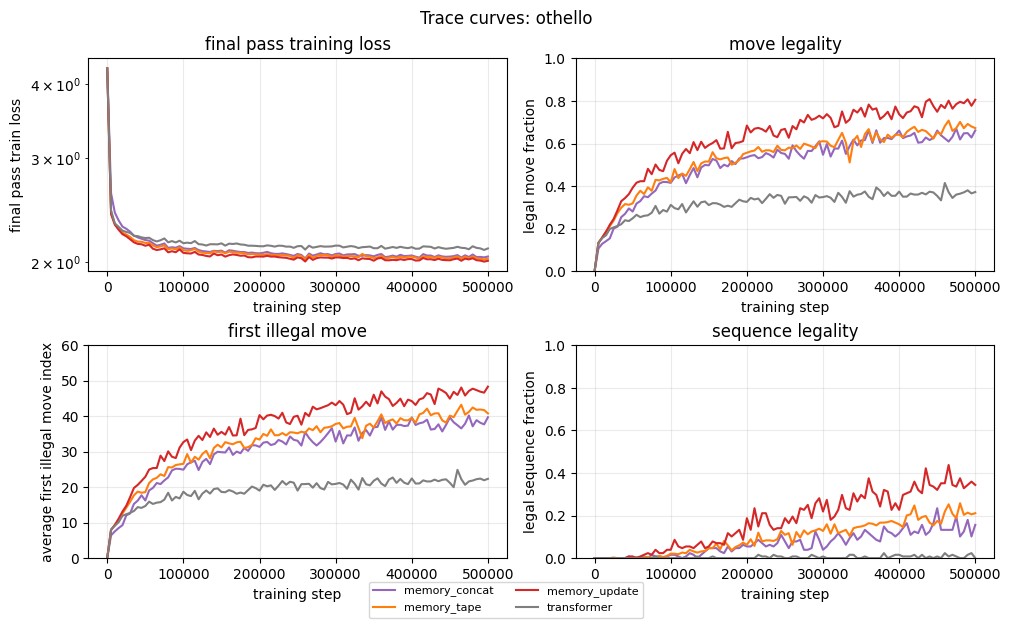

In [657]:
def grouped_mean(rows, metric, *, kind):
    grouped = defaultdict(list)
    for row in rows:
        if row.get("kind") != kind:
            continue
        value = row.get(metric)
        if value is None and kind == "train" and metric == "last_pass_loss":
            value = row.get("train_loss")
        if value is None:
            continue
        key = (row["task"], row["architecture"], row["step"])
        grouped[key].append(float(value))

    out = []
    for (task, arch, step), values in sorted(grouped.items()):
        out.append({
            "task": task,
            "architecture": arch,
            "step": step,
            "value": sum(values) / len(values),
        })
    return out


def plot_task_panels(rows, task):
    panels = [
        ("last_pass_loss", "final pass train loss", "final pass training loss", "train", "log", None),
        ("token_legality", "legal move fraction", "move legality", "eval", None, (0, 1)),
        ("mean_legal_len", "average first illegal move index", "first illegal move", "eval", None, (0, 60)),
        ("sequence_legality", "legal sequence fraction", "sequence legality", "eval", None, (0, 1)),
    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10, 6),
        squeeze=False,
        constrained_layout=True,
    )

    legend_handles = None
    legend_labels = None

    for ax, (metric, ylabel, title, kind, yscale, ylim) in zip(axes.flat, panels):
        metric_rows = grouped_mean(rows, metric, kind=kind)
        task_rows = [row for row in metric_rows if row["task"] == task]

        if not task_rows:
            ax.set_title(title)
            ax.set_axis_off()
            continue

        grouped = defaultdict(list)
        for row in task_rows:
            grouped[row["architecture"]].append(row)

        for arch, items in sorted(grouped.items()):
            items = sorted(items, key=lambda item: item["step"])
            ax.plot(
                [item["step"] for item in items],
                [item["value"] for item in items],
                label=f"{arch}",
                color=ARCH_COLORS.get(arch, "tab:blue"),
                markersize=3,
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_title(title)
        ax.set_xlabel("training step")
        ax.set_ylabel(ylabel)

        if yscale is not None:
            ax.set_yscale(yscale)

        if ylim is not None:
            ax.set_ylim(*ylim)

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.03),
            ncol=2,
            fontsize=8,
        )

    fig.suptitle(f"Trace curves: {task}")
    plt.show()


for task in sorted({row["task"] for row in rows}):
    plot_task_panels(rows, task)